# Recovery Algorithm

*On average*, the protection of input states $\alpha|00...0\rangle + \beta|11...1\rangle $ produces an improvement over bare noise if $n\beta > 2$  (more prominent for bigger $m$), see Fig.3.

In [41]:
using LinearAlgebra
using Plots
using Revise
using Latexify
using Random
using StatsBase
using Logging, TerminalLoggers, ProgressLogging
# Display debug messages
global_logger(TerminalLogger(stderr, Logging.Debug))

includet("../julia/src/UnitaryDilation/UnitaryDilation.jl")
includet("../julia/src/PetzMaps.jl")
includet("../julia/src/utils.jl")

using .UnitaryDilation
using .PetzMaps

In [130]:
function get_kraus_operators(noise, gamma, t)
  if noise == "amplitude_damping"
    return get_amplitudedamping_operators(gamma, t)
  elseif noise == "dephasing"
    return get_dephasing_operators(gamma, t)
  elseif noise == "bitflip"
    return get_bitflip_operators(gamma, t)
  else
    error("Unknown noise model: $noise")
  end

end

function apply_noise(model, ρ, n_qubits)
  ρf = apply_channel(model.kraus_fwd, ρ, n_qubits)
  # Enforce physicality (hermitianicity and trace 1)
  # enforce_physical!(ρf)
  return ρf
end


function recovery(model, ρ)
  ρr, η = apply_collision(model, ρ)
  # enforce_physical!(ρr)
  return ρr, η
end

recovery (generic function with 1 method)

## Setup

In [192]:
n_qubits = 2
beta = 3.0
gamma = 1.0
dt = 0.1
noise = "bitflip"
n_steps = 2

fidelities = Float64[]
fidelities_ref = Float64[]  # Store the fidelities of the noisy state evolving without recovery

c1 = c2 = 0

# Random but reproducible states
seed = 42
rng = Xoshiro(seed)

Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e)

### Initial States
We create the recovery state `sigma` and a random initial state

In [193]:
# Choose a reference state for the recovery
sigma = thermal_state(n_qubits, beta)
# Start from a random pure state
psi = random_state(n_qubits; seed=seed)
ρ0 = psi * psi'

display(latexify(sigma; fmt="%.3f")) # display as LaTeX table
display(latexify(ρ0; fmt="%.3f"))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.499+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
-0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
-0.0\mathit{i} & -0.0\mathit{i} & 0.001+0.000\mathit{i} & 0.0\mathit{i} \\
-0.0\mathit{i} & -0.0\mathit{i} & -0.0\mathit{i} & 0.499+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

L"\begin{equation}
\left[
\begin{array}{cccc}
0.550+0.000\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & -0.342-0.361\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} \\
-0.342+0.361\mathit{i} & 0.0\mathit{i} & 0.0\mathit{i} & 0.450+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

### Noise

In [194]:
noise_probabilities = [
  (0.75, "bitflip"),
  (0.25, "dephasing"),
]

# ======================================
# Precompute the supermaps once
mutable struct NoiseObj{T<:Number}
  name::String
  probability::Float64
  kraus::Vector{Matrix{T}}
  supermap_petz::Matrix{T}
  supermap_noise::Matrix{T}
  supermap::Matrix{T}
end

function NoiseObj(noise::String, p::Float64, gamma::Float64, sigma::Matrix{T}, t::Float64) where T
  kraus = get_kraus_operators(noise, gamma, t)
  n_qubits = Int(log2(size(sigma, 1)))
  model = CollisionModel(kraus, sigma, n=n_qubits)
  M_petz, M_noise = build_superoperators(model)
  return NoiseObj{T}(noise, p, kraus, M_petz, M_noise, M_noise)
end

noise_options = [
  NoiseObj(noise_model[2], noise_model[1], gamma, sigma, dt)
  for noise_model in noise_probabilities
]

# ======================================

# Choose randomly a noise model
noise = sample(rng,
  [n[2] for n in noise_probabilities], 
  Weights([n[1] for n in noise_probabilities])
)
println("Chosen noise:\t\t$noise")
# Take the relevant Kraus operators
real_kraus = get_kraus_operators(noise, gamma, dt)
real_model = CollisionModel(real_kraus, sigma, n=n_qubits)

# Take an initial guess for the noise model
noise_guess = sample(rng, [n for n in noise_options])
# Initialize the collision model with the superoperator,
#  as this will be easier to update iteratively
M_petz, M_noise = noise_guess.supermap_petz, noise_guess.supermap_noise
M_total = M_noise
model = CollisionModel(M_total, sigma)
println("Initial noise guess:\t$(noise_guess.name)")
println("Size of superoperator:\t$(size(M_total))")

Chosen noise:		bitflip
Initial noise guess:	bitflip
Size of superoperator:	(16, 16)


## Algorithm

### Step 1
We apply the noise and recover the state with the Petz collision modelmap.
- `rho1`: control state where only noise is applied
- `rho2`: state where noise + collision is applied
- `rho3`: benchmark state where noise + Petz map is applied

We keep the variable `rho2_` as intermediate state after the noise but before the recovery.

This will be used to test ancilla outputs given a known noise.


In [195]:
rho1 = copy(ρ0)
rho2 = copy(ρ0)
rho3 = copy(ρ0)

rho1 = apply_channel(real_kraus, rho1, n_qubits)
rho2_ = apply_channel(real_kraus, rho2, n_qubits)
rho3_ = apply_channel(real_kraus, rho3, n_qubits)

println("Fidelity after noise: ", fidelity(ρ0, rho1))

Fidelity after noise: 0.8307902405361037


### Step 2
We recover the state `rho2` with the Unitary dilation of the Petz map defined by the Kraus operators of the **guessed** noise.
Remember that `rho2` starts in the same state of `rho1` after the noise.

In [196]:
rho2, η = recovery(model, rho2_)
rho3 = recovery_map(real_kraus, sigma, rho3, n_qubits)

push!(fidelities_ref, fidelity(ρ0, rho1))
push!(fidelities, fidelity(ρ0, rho2))

display(latexify(rho2; fmt="%.3f"))
println("Fidelity wrt initial state: ", fidelity(ρ0, rho2))
println("Fidelity wrt reference state: ", fidelity(sigma, rho2))
println("Benchmark fidelity: ", fidelity(ρ0, rho3))

L"\begin{equation}
\left[
\begin{array}{cccc}
0.539-0.000\mathit{i} & 0.000-0.000\mathit{i} & 0.000-0.000\mathit{i} & -0.341-0.290\mathit{i} \\
0.000+0.000\mathit{i} & 0.001-0.000\mathit{i} & -0.001-0.000\mathit{i} & -0.000-0.000\mathit{i} \\
0.000+0.000\mathit{i} & -0.001+0.000\mathit{i} & 0.001-0.000\mathit{i} & -0.000-0.000\mathit{i} \\
-0.341+0.290\mathit{i} & -0.000+0.000\mathit{i} & -0.000+0.000\mathit{i} & 0.459+0.000\mathit{i} \\
\end{array}
\right]
\end{equation}
"

Fidelity wrt initial state: 0.945598146091174
Fidelity wrt reference state: 0.7170925572858565
Benchmark fidelity: 0.9942812836475641


### Step 3
We measure the output ancilla and compare it with the possible options, given the possible noises.

In [197]:
function discrimin(ρ_test, ρ1, ρ2)
    # Compute the difference of density matrices
    Δρ = ρ1 - ρ2
    
    # Diagonalize to find eigenvalues and eigenvectors
    eigen_decomp = eigen(Hermitian(Δρ))
    eigenvalues = eigen_decomp.values
    eigenvectors = eigen_decomp.vectors
    
    # Construct Π₁: projector onto positive eigenspace
    Π1 = zeros(ComplexF64, size(ρ1))
    for i in eachindex(eigenvalues)
        if eigenvalues[i] > 1e-10  # positive eigenvalue (with numerical tolerance)
            v = eigenvectors[:, i]
            Π1 += v * v'  # Add rank-1 projector |v⟩⟨v|
        end
    end
    
    # Construct Π₂: complement projector
    Π2 = I - Π1
    
    # Compute probabilities
    p1 = real(tr(Π1 * ρ_test))
    p2 = real(tr(Π2 * ρ_test))
    
    return [p1, p2]
end

function update_noise_history!(noise_obj)
  M_petz, M_noise = noise_obj.supermap_petz, noise_obj.supermap_noise
  noise_obj.supermap = M_noise * M_petz * noise_obj.supermap
end

function measure_ancilla(η, rho, noise_options, sigma, n_qubits)
  ancilla_options = []
  for option in noise_options
    _model = CollisionModel(option.supermap, sigma)
    _, _η = recovery(_model, rho)
    push!(ancilla_options, _η)
  end

  weights = discrimin(η, ancilla_options...)
  @debug "Discrimination weights: $weights"
  povm = sample(rng, [1, 2], Weights(weights))
  return povm
end


povm = measure_ancilla(η, rho1, noise_options, sigma, n_qubits)
println("Measure output: $povm")

┌ Debug: Discrimination weights: [0.5335065741161473, 0.4664934254854469]
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sdnNjb2RlLXJlbW90ZQ==.jl:43


Measure output: 1


### Step 4
Choose the next noise guess

In [198]:
function update_noise_guess(povm, c1, c2, noise_options)
  # update the count of noise choices
  if povm == 1
    c1 += 1
  else
    c2 += 1
  end

  if c1 > c2 || 10*(c1 - c2) == (povm - 2)
    # Assume the first noise model
    noise_guess = noise_options[1]
  elseif c2 > c1 || 10*(c1 - c2) == (povm - 1)
    # Assume the second noise model
    noise_guess = noise_options[2]
  end
  return noise_guess, c1, c2
end

noise_guess, c1, c2 = update_noise_guess(povm, c1, c2, noise_options)
println("Updated noise guess:\t$(noise_guess.name)")

Updated noise guess:	bitflip


### Step 5 - Iterate
Update the complete map. 
This requires using the supermap operators and multiplying them

In [199]:
function iterate_recovery(rho1, rho2, noise_guess, M_total, c1, c2, fidelities, ref, args...)
  ρ0, sigma, real_kraus, n_qubits, noise_options = args

  M_petz, M_noise = noise_guess.supermap_petz, noise_guess.supermap_noise
  M_total = (M_noise * M_petz) * M_total
  model = CollisionModel(M_total, sigma)
  
  # 1. Apply noise
  rho1 = apply_channel(real_kraus, rho1, n_qubits)
  rho2_ = apply_channel(real_kraus, rho2, n_qubits)
  
  # 2. Recovery
  rho2, η = recovery(model, rho2_)
  
  println("Fidelity wrt initial state: ", fidelity(ρ0, rho2))
  println("Fidelity wrt reference state: ", fidelity(sigma, rho2))
  
  push!(ref, fidelity(ρ0, rho1))
  push!(fidelities, fidelity(ρ0, rho2))
  
  # 3. Measure Ancilla
  for option in noise_options
    update_noise_history!(option)
  end
  povm = measure_ancilla(η, rho2_, noise_options, sigma, n_qubits)
  println("Measure output: $povm")
  
  noise_guess, c1, c2 = update_noise_guess(povm, c1, c2, noise_options)
  println("Updated noise guess:\t$(noise_guess.name)")

  return rho1, rho2, noise_guess, M_total, c1, c2
end

args = (ρ0, sigma, real_kraus, n_qubits, noise_options)
for step in 1:1
  println("=== Iteration $step ===")
  rho1, rho2, noise_guess, M_total, c1, c2 = 
    iterate_recovery(rho1, rho2, noise_guess, M_total, c1, c2, fidelities, fidelities_ref, args...)
  println()
end

=== Iteration 1 ===
Fidelity wrt initial state: 0.8695321176526125
Fidelity wrt reference state: 0.8121571484484562
Measure output: 2
Updated noise guess:	bitflip



┌ Debug: Discrimination weights: [0.5756396674739003, 0.42436033172770493]
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sdnNjb2RlLXJlbW90ZQ==.jl:43


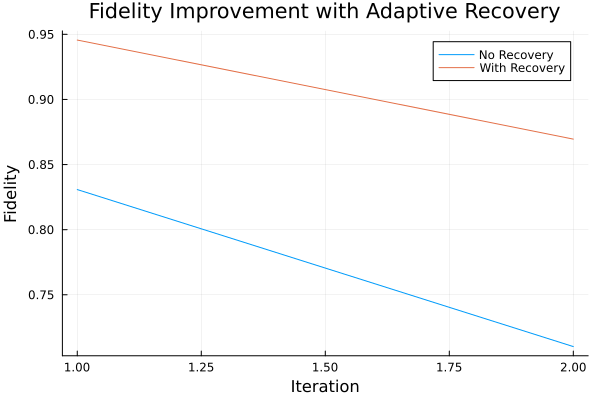

In [200]:
plot([fidelities_ref fidelities], 
  labels=["No Recovery" "With Recovery"], 
  xlabel="Iteration", ylabel="Fidelity", 
  title="Fidelity Improvement with Adaptive Recovery"
)

---

## Use Structures to store variables (cleaner interface)

In [201]:
# 1. Static Configuration: Passed once, never changes
struct RecoveryConfig{T}
    ρ0::T
    sigma::T
    real_kraus
    n_qubits::Int
end

# 2. Dynamic State: Updates every iteration
mutable struct RecoveryState{T, M, G, C, O}
    rho1::T
    rho2::T
    M_total::M
    noise_guess::G
    c1::C
    c2::C
    noise_options::O
end

# 3. Logs: Keep metrics separate from logic
struct RecoveryLogs
    fidelities::Vector{Float64}
    ref_fidelities::Vector{Float64}
end
# Helper to initialize empty logs
RecoveryLogs() = RecoveryLogs(Float64[], Float64[]);

In [202]:
function step_recovery!(state::RecoveryState, config::RecoveryConfig, logs::RecoveryLogs)

    # 0. Setup models
    M_petz = state.noise_guess.supermap_petz
    M_noise = state.noise_guess.supermap_noise
    
    # Update M_total in place or reassign in the struct
    state.M_total = (M_noise * M_petz) * state.M_total
    model = CollisionModel(state.M_total, config.sigma)
    
    # 1. Apply noise (update rho1 and create intermediate rho2_)
    state.rho1 = apply_channel(config.real_kraus, state.rho1, config.n_qubits)
    rho2_noisy = apply_channel(config.real_kraus, state.rho2, config.n_qubits)
    
    # 2. Recovery
    # Update rho2 in the state struct
    state.rho2, η = recovery(model, rho2_noisy)
    
    # 3. Logging
    fid_initial = fidelity(config.ρ0, state.rho2)
    fid_ref = fidelity(config.sigma, state.rho2)
    fid_track = fidelity(config.ρ0, state.rho1)

    @debug "Fidelity wrt initial state: $fid_initial"
    @debug "Fidelity wrt reference state: $fid_ref"
    
    push!(logs.ref_fidelities, fid_track)
    push!(logs.fidelities, fid_initial)
    
    # 4. Measure Ancilla and Update Guess
    for option in state.noise_options
        update_noise_history!(option)
    end
    povm = measure_ancilla(η, rho2_noisy, state.noise_options, config.sigma, config.n_qubits)
    @debug "Measure output: $povm"
    
    # Update the remaining state variables
    state.noise_guess, state.c1, state.c2 = update_noise_guess(povm, state.c1, state.c2, state.noise_options)
    @debug "Updated noise guess:\t$(state.noise_guess.name)"

    # Return nothing (or the state) because we modified the struct in-place
    return nothing 
end

step_recovery! (generic function with 1 method)

In [212]:
# 1. Initialization
config = RecoveryConfig(ρ0, sigma, real_kraus, n_qubits)
noise_guess = sample(rng, [n for n in noise_options])
@info "Initial noise guess:\t$(noise_guess.name)"
rho1, rho2 = copy(ρ0), copy(ρ0)
M_total = noise_guess.supermap_noise
c1 = c2 = 0
state = RecoveryState(rho1, rho2, M_total, noise_guess, c1, c2, noise_options)
logs = RecoveryLogs()

# 2. The Loop
for step in 1:2
    @info "=== Iteration $step ==="
    step_recovery!(state, config, logs)
end

# 3. Access results
@info "Fidelities of reconstructed state $(logs.fidelities)"
@info "Fidelities of reference state $(logs.ref_fidelities)"

[ Info: Initial noise guess: bitflip
[ Info: === Iteration 1 ===
┌ Debug: Fidelity wrt initial state: 0.9033852455393113
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sdnNjb2RlLXJlbW90ZQ==.jl:24
┌ Debug: Fidelity wrt reference state: 0.7788324953410948
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sdnNjb2RlLXJlbW90ZQ==.jl:25
┌ Debug: Discrimination weights: [0.46213199720803716, 0.5378680023935546]
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sdnNjb2RlLXJlbW90ZQ==.jl:43
┌ Debug: Measure output: 2
└ @ Main /home/fedesss/UNIPA/COLLISION_MODELS/shooting-decoherences/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X31sdnNjb2RlLXJlbW90ZQ==.jl:35
┌ Debug: Updated noise guess: dephasing
└ @ Main /home/fedesss/UNIPA/COLLISION_MODE

---
## Iterate over many Random States
Now we setup a utility function to run this experiment for different random states.

The final output fidelities, `f1s` and `f2s`, are mediated across all the initial states, timestep by timestep.
As usual, one represents the state undergoing a noisy free evolution and the second represent the effect of the adaptive recovery.

In [ ]:
function recovery_random_states(n_states; steps=2)
  f1s = zeros(Float64, steps)
  f2s = zeros(Float64, steps)
  @progress name="Average Recovery" for state in 1:n_states
    # 1. Initialization
    sigma = thermal_state(n_qubits, beta)
    ψ0 = random_state(n_qubits)
    config = RecoveryConfig(ρ0, sigma, real_kraus, n_qubits)
    noise_guess = sample(rng, [n for n in noise_options])
    rho1, rho2 = copy(ρ0), copy(ρ0)
    M_total = noise_guess.supermap_noise
    c1 = c2 = 0
    state = RecoveryState(rho1, rho2, M_total, noise_guess, c1, c2, noise_options)
    logs = RecoveryLogs()

    # 2. The Loop
    for step in 1:steps
        step_recovery!(state, config, logs)
    end
    f1s .+= logs.ref_fidelities
    f2s .+= logs.fidelities
  end
  return f1s ./ n_states, f2s ./ n_states
end

# We disable debug messages for this bulk run
temp_logger = TerminalLogger(stderr, Logging.Info)
fidelities = Float64[]
with_logger(temp_logger) do
  global fidelities = recovery_random_states(500; steps=50);
end

plot([fidelities[1] fidelities[2]], 
  labels=["No Recovery" "With Recovery"], 
  xlabel="Iteration", ylabel="Fidelity", 
  title="Average Fidelity Improvement with Adaptive Recovery"
)